[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20Profundo/Programação_com_Pytorch.ipynb)

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Fundamentos de Programação com PyTorch

Este notebook apresenta os conceitos fundamentais de programação com **PyTorch**, uma das principais bibliotecas para desenvolvimento de modelos de aprendizado profundo.

O objetivo é:

- definir, criar e manipular tensores;
- entender a diferença entre NumPy e PyTorch;
- usar GPU quando disponível;
- compreender o mecanismo de diferenciação automática `autograd`;
- criar modelos com `torch.nn`;
- definir função de perda e otimizador;
- implementar um laço de treinamento;
- treinar uma rede neural simples para classificação.



## PyTorch (definição)

O **PyTorch** é uma biblioteca de programação científica e aprendizado profundo baseada em tensores. Ele permite construir, treinar e avaliar redes neurais de forma flexível.

Principais características:

- estrutura semelhante ao NumPy;
- suporte a GPU;
- diferenciação automática;
- construção dinâmica de grafos computacionais;
- integração com redes neurais profundas por meio do módulo `torch.nn`.

A unidade fundamental do PyTorch é o **tensor**.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Versão do PyTorch:", torch.__version__)

Versão do PyTorch: 2.12.0+cpu


## Trabalhando com CPU ou GPU

É comum treinar redes neurais usando GPU. No Colab, é possível ativar GPU em:

**Ambiente de execução → Alterar tipo de ambiente de execução → GPU**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo disponível:", device)

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))

Dispositivo disponível: cpu


## Definição de Tensores

Um **tensor** é uma estrutura de dados multidimensional que pode representar:

- escalar: tensor de dimensão 0
- vetor: tensor de dimensão 1
- matriz: tensor de dimensão 2
- imagens, vídeos e lotes de dados: tensores de dimensões maiores.

In [4]:
# Escalar
x0 = torch.tensor(5)

# Vetor
x1 = torch.tensor([1, 2, 3])

# Matriz
x2 = torch.tensor([[1, 2, 3],
                   [4, 5, 6]])

print("Escalar:", x0)
print("Vetor:", x1)
print("Matriz:\n", x2)

print("Dimensão do escalar:", x0.ndim)
print("Dimensão do vetor:", x1.ndim)
print("Dimensão da matriz:", x2.ndim)
print("Formato da matriz:", x2.shape)

Escalar: tensor(5)
Vetor: tensor([1, 2, 3])
Matriz:
 tensor([[1, 2, 3],
        [4, 5, 6]])
Dimensão do escalar: 0
Dimensão do vetor: 1
Dimensão da matriz: 2
Formato da matriz: torch.Size([2, 3])


## Tensores Especiais

O PyTorch possui funções para criar tensores preenchidos com zeros, uns, valores aleatórios ou intervalos numéricos.

In [5]:
zeros = torch.zeros(3, 4)
ones = torch.ones(3, 4)
rand = torch.rand(3, 4)
normal = torch.randn(3, 4)
intervalo = torch.arange(0, 10, 2)

print("Zeros:\n", zeros)
print("Uns:\n", ones)
print("Aleatório uniforme:\n", rand)
print("Aleatório normal:\n", normal)
print("Intervalo:", intervalo)

Zeros:
 tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
Uns:
 tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])
Aleatório uniforme:
 tensor([[0.6644, 0.7979, 0.4440, 0.5849],
        [0.4859, 0.6132, 0.6613, 0.5430],
        [0.2299, 0.5250, 0.9319, 0.7779]])
Aleatório normal:
 tensor([[ 0.6584, -1.4245, -0.5585, -0.5191],
        [-0.3459, -1.8544,  0.7726,  0.8277],
        [ 1.2120, -0.2118,  2.7332, -1.2239]])
Intervalo: tensor([0, 2, 4, 6, 8])


## Tipos de Dados em Pytorch

Assim como em C, Python e NumPy, os tensores possuem tipos de dados.

Alguns tipos comuns:

- `torch.float32`
- `torch.float64`
- `torch.int64`
- `torch.bool`

In [6]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([1.0, 2.0, 3.0])
c = torch.tensor([True, False, True])

print(a, a.dtype)
print(b, b.dtype)
print(c, c.dtype)

# Convertendo tipo
b_int = b.to(torch.int64)
print(b_int, b_int.dtype)

tensor([1, 2, 3]) torch.int64
tensor([1., 2., 3.]) torch.float32
tensor([ True, False,  True]) torch.bool
tensor([1, 2, 3]) torch.int64


## Operações com Tensores

As operações com tensores são semelhantes às operações com arrays NumPy.

In [7]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Soma:", a + b)
print("Subtração:", a - b)
print("Multiplicação elemento a elemento:", a * b)
print("Divisão:", b / a)
print("Potência:", a ** 2)
print("Média:", a.mean())
print("Soma dos elementos:", a.sum())

Soma: tensor([5., 7., 9.])
Subtração: tensor([-3., -3., -3.])
Multiplicação elemento a elemento: tensor([ 4., 10., 18.])
Divisão: tensor([4.0000, 2.5000, 2.0000])
Potência: tensor([1., 4., 9.])
Média: tensor(2.)
Soma dos elementos: tensor(6.)


## Produto Matricial

Uma operação muito comum em redes neurais artificiais é o produto matricial, seja:


$$
Y = XW + b
$$

onde:

- \(X\) representa os dados de entrada;
- \(W\) representa os pesos;
- \(b\) representa o bias;
- \(Y\) representa a saída linear.

In [8]:
X = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])

W = torch.tensor([[0.5],
                  [0.2]])

b = torch.tensor([0.1])

# Produto matricial
Y = X @ W + b

print("X shape:", X.shape)
print("W shape:", W.shape)
print("Y:\n", Y)

X shape: torch.Size([3, 2])
W shape: torch.Size([2, 1])
Y:
 tensor([[1.0000],
        [2.4000],
        [3.8000]])


## Indexando e Fatiando Tensores

É possível acessar partes específicas de um tensor usando indexação.

In [9]:
A = torch.tensor([[10, 20, 30],
                  [40, 50, 60],
                  [70, 80, 90]])

print("Matriz A:\n", A)
print("Primeira linha:", A[0])
print("Primeira coluna:", A[:, 0])
print("Elemento linha 1, coluna 2:", A[1, 2])
print("Submatriz:\n", A[0:2, 1:3])

Matriz A:
 tensor([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]])
Primeira linha: tensor([10, 20, 30])
Primeira coluna: tensor([10, 40, 70])
Elemento linha 1, coluna 2: tensor(60)
Submatriz:
 tensor([[20, 30],
        [50, 60]])


## Mudando o formato: `reshape` e `view`

Muitas vezes é necessário alterar o formato dos dados.

Por exemplo, uma imagem 28 × 28 pode ser transformada em um vetor com 784 elementos.

In [10]:
x = torch.arange(0, 12)
print("Original:", x)
print("Shape original:", x.shape)

x2 = x.reshape(3, 4)
print("\nApós reshape:\n", x2)
print("Novo shape:", x2.shape)

x3 = x2.reshape(-1)
print("\nVetor novamente:", x3)

Original: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Shape original: torch.Size([12])

Após reshape:
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Novo shape: torch.Size([3, 4])

Vetor novamente: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


## Conversão entre NumPy e PyTorch

É comum converter dados entre NumPy e PyTorch.

In [11]:
array_np = np.array([1, 2, 3], dtype=np.float32)
tensor_torch = torch.from_numpy(array_np)

print("Array NumPy:", array_np)
print("Tensor PyTorch:", tensor_torch)

novo_array = tensor_torch.numpy()
print("Tensor convertido para NumPy:", novo_array)

Array NumPy: [1. 2. 3.]
Tensor PyTorch: tensor([1., 2., 3.])
Tensor convertido para NumPy: [1. 2. 3.]


## Processando tensores em GPU

Para usar GPU, os tensores e o modelo precisam estar no mesmo dispositivo.

In [12]:
x = torch.rand(3, 3)
print("Dispositivo original:", x.device)

x = x.to(device)
print("Dispositivo após envio:", x.device)

Dispositivo original: cpu
Dispositivo após envio: cpu


## Diferenciação Automática com `autograd`

Uma das funcionalidades mais importantes do PyTorch é o cálculo automático de gradientes.

Considere a função:

$$
y = x^2 + 2x + 1
$$

A derivada é:

$$
\frac{dy}{dx} = 2x + 2
$$

Para \(x = 3\):

$$
\frac{dy}{dx} = 8
$$

In [13]:
x = torch.tensor(3.0, requires_grad=True)

y = x**2 + 2*x + 1

print("y =", y.item())

# Calcula o gradiente dy/dx
y.backward()

print("Gradiente dy/dx:", x.grad.item())

y = 16.0
Gradiente dy/dx: 8.0


## Gradiente com Vários Parâmetros

Agora considere:

$$
z = x^2 + y^3
$$

O PyTorch calcula automaticamente:

$$
\frac{\partial z}{\partial x}
$$

e

$$
\frac{\partial z}{\partial y}
$$

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

z = x**2 + y**3
z.backward()

print("z =", z.item())
print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())

## Regressão Linear com PyTorch

O objetivo é ajustar o seguinte modelo:

$$
y = wx + b
$$

O objetivo é encontrar os valores de \(w\) e \(b\) a partir dos dados.

In [ ]:
# Gerando dados sintéticos
torch.manual_seed(42)

X = torch.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X + 1 + torch.randn(X.shape) * 1.5

plt.scatter(X.numpy(), y.numpy())
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dados sintéticos")
plt.grid(True)
plt.show()

In [ ]:
# Parâmetros do modelo
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

learning_rate = 0.01
losses = []

for epoch in range(1000):
    # Forward pass
    y_pred = X * w + b

    # Função de perda MSE
    loss = torch.mean((y_pred - y)**2)

    # Backward pass
    loss.backward()

    # Atualização manual dos parâmetros
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    # Zerar os gradientes acumulados
    w.grad.zero_()
    b.grad.zero_()

    losses.append(loss.item())

print("w aprendido:", w.item())
print("b aprendido:", b.item())

w aprendido: 1.992496132850647
b aprendido: 1.1249574422836304


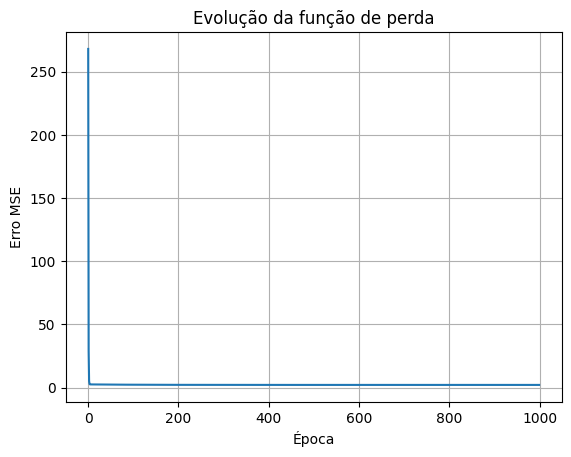

In [ ]:
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Erro MSE")
plt.title("Evolução da função de perda")
plt.grid(True)
plt.show()

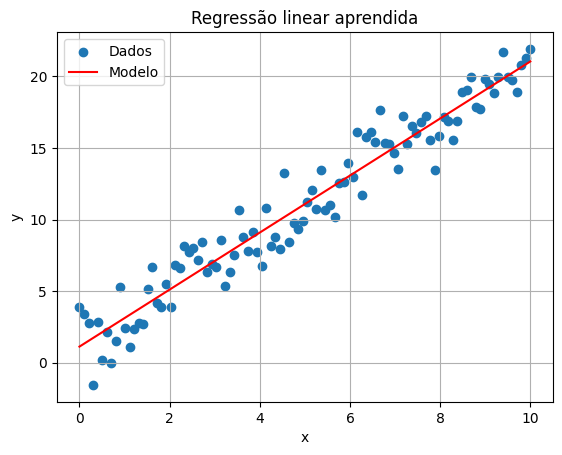

In [ ]:
with torch.no_grad():
    y_pred = X * w + b

plt.scatter(X.numpy(), y.numpy(), label="Dados")
plt.plot(X.numpy(), y_pred.numpy(), label="Modelo", c='red')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão linear aprendida")
plt.legend()
plt.grid(True)
plt.show()

## `torch.nn`

O módulo `torch.nn` fornece componentes prontos para construir redes neurais.

Uma camada linear é representada por:

```python
nn.Linear(entrada, saída)
```

Ela implementa:

$$
y = xW^T + b
$$

In [ ]:
import torch.nn as nn

modelo = nn.Linear(1, 1)
print(modelo)

for nome, parametro in modelo.named_parameters():
    print(nome, parametro.data)

Linear(in_features=1, out_features=1, bias=True)
weight tensor([[0.0028]])
bias tensor([-0.3721])


## Regressão Linear Usando `nn.Module` e `optim`



In [ ]:
import torch.optim as optim

# Modelo
model = nn.Linear(1, 1)

# Função de perda
criterion = nn.MSELoss()

# Otimizador
optimizer = optim.SGD(model.parameters(), lr=0.01)

losses = []

for epoch in range(1000):
    # Forward
    y_pred = model(X)
    loss = criterion(y_pred, y)

    # Backward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

print("Parâmetros aprendidos:")
for nome, parametro in model.named_parameters():
    print(nome, parametro.data)

Parâmetros aprendidos:
weight tensor([[1.9927]])
bias tensor([1.1237])


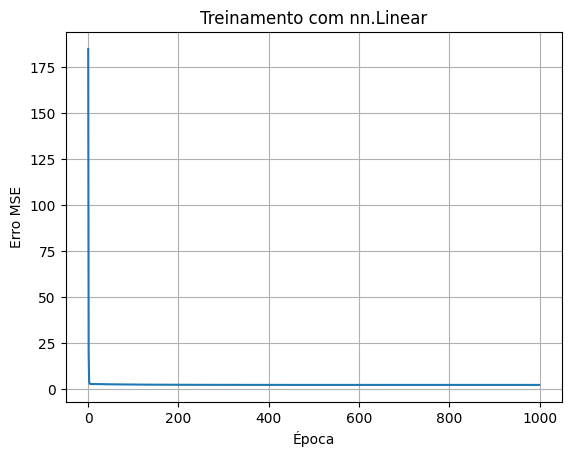

In [ ]:
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Erro MSE")
plt.title("Treinamento com nn.Linear")
plt.grid(True)
plt.show()

## Rede Neural com Classe

Em PyTorch, uma forma muito comum de criar modelos é herdar de `nn.Module`.

In [ ]:
class MinhaRede(nn.Module):
    def __init__(self):
        super().__init__()
        self.camada1 = nn.Linear(4, 16)
        self.camada2 = nn.Linear(16, 8)
        self.camada3 = nn.Linear(8, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.camada1(x))
        x = self.relu(self.camada2(x))
        x = self.camada3(x)
        return x

rede = MinhaRede()
print(rede)

MinhaRede(
  (camada1): Linear(in_features=4, out_features=16, bias=True)
  (camada2): Linear(in_features=16, out_features=8, bias=True)
  (camada3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)


## Criando uma RNN com Pytorch (IRIS dataset)

O objetivo deste exemplo é classificar flores em três classes com base em quatro atributos.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo para tensores
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([120, 4])
y_train shape: torch.Size([120])


## Modelo de classificação

Para classificação multiclasse, a última camada terá 3 neurônios, um para cada classe.

A função de perda `CrossEntropyLoss` espera a saída bruta da rede, chamada de **logits**.

In [ ]:
class ClassificadorIris(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.net(x)

model = ClassificadorIris().to(device)
print(model)

ClassificadorIris(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
accuracies = []

epochs = 200

for epoch in range(epochs):
    model.train()

    logits = model(X_train)
    loss = criterion(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    with torch.no_grad():
        pred = torch.argmax(logits, dim=1)
        acc = (pred == y_train).float().mean().item()
        accuracies.append(acc)

print("Treinamento finalizado")

Treinamento finalizado


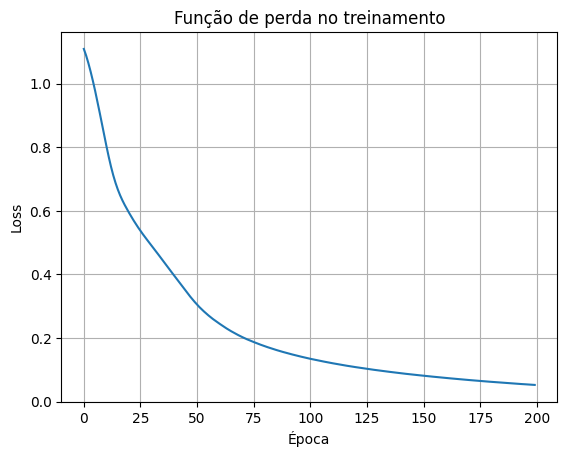

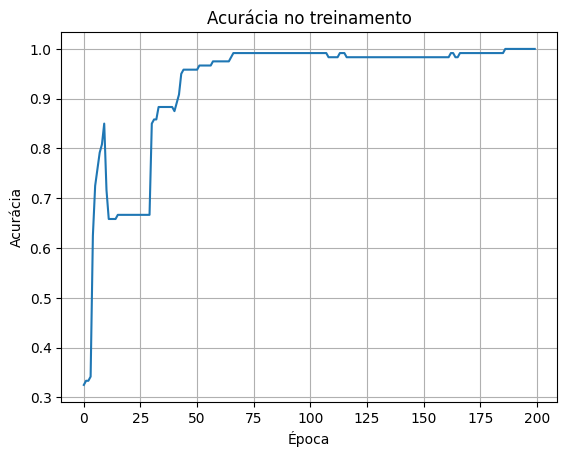

In [ ]:
plt.plot(losses)
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Função de perda no treinamento")
plt.grid(True)
plt.show()

plt.plot(accuracies)
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia no treinamento")
plt.grid(True)
plt.show()

## Avaliação do Modelo

Avaliação do modelo após o treinamento.

In [ ]:
model.eval()

with torch.no_grad():
    logits_test = model(X_test)
    y_pred = torch.argmax(logits_test, dim=1)

acc = accuracy_score(y_test.cpu().numpy(), y_pred.cpu().numpy())
print("Acurácia no teste:", acc)

Acurácia no teste: 0.9333333333333333


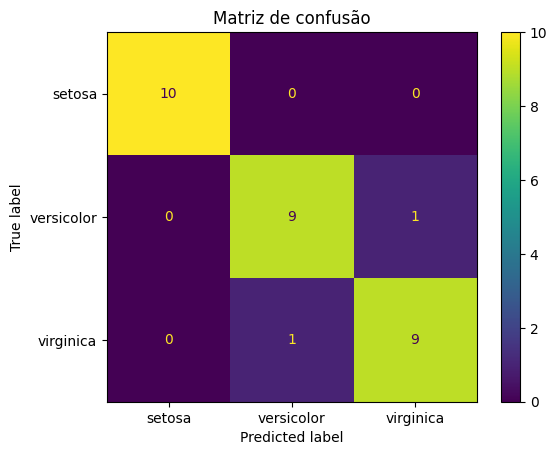

In [ ]:
cm = confusion_matrix(y_test.cpu().numpy(), y_pred.cpu().numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("Matriz de confusão")
plt.show()

## Usando `Dataset` e `DataLoader`

Para datasets maiores é recomendado utilizar `Dataset` e `DataLoader`.

O `DataLoader` permite:

- dividir os dados em mini-batches;
- embaralhar os dados;
- facilitar o treinamento em grandes bases.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

for batch_X, batch_y in train_loader:
    print("Batch X:", batch_X.shape)
    print("Batch y:", batch_y.shape)
    break

Batch X: torch.Size([16, 4])
Batch y: torch.Size([16])


## Treinando o Modelo com Mini-batches



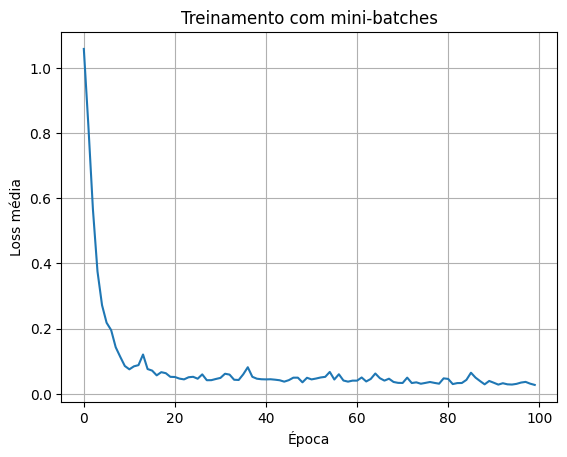

In [ ]:
model_batch = ClassificadorIris().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_batch.parameters(), lr=0.01)

losses_batch = []

epochs = 100

for epoch in range(epochs):
    model_batch.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        logits = model_batch(batch_X)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses_batch.append(epoch_loss / len(train_loader))

plt.plot(losses_batch)
plt.xlabel("Época")
plt.ylabel("Loss média")
plt.title("Treinamento com mini-batches")
plt.grid(True)
plt.show()

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* As imagens foram geradas pelo chatgpt.